In [ ]:
# =====================================================
# IMPORT LIBRARY
# =====================================================

# Standard Library
import os
import time
import random
import shutil

# Data Processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image Processing
from PIL import Image

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential, Model, load_model

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Activation,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    Reshape,
    Add,
    RandomRotation,
    RandomFlip
)

from tensorflow.keras.callbacks import (
    Callback,
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import plot_model

# Transfer Learning
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# Image Utilities
from tensorflow.keras.preprocessing import image

# Google Colab
from google.colab import drive, files


# =====================================================
# RANDOM SEED
# =====================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# =====================================================
# GPU CHECK
# =====================================================

print("=" * 50)
print("GPU INFORMATION")
print("=" * 50)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU DETECTED")
    print(gpus)
else:
    print("GPU NOT DETECTED")

print("=" * 50)

GPU INFORMATION
GPU DETECTED
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **LOAD DATA**

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


Drive Storage to Lokal

In [ ]:
!cp -r "/content/drive/MyDrive/capstone/dataset_food" "/content/"

In [ ]:
!cp -r "/content/drive/MyDrive/capstone/model_2_best.keras" "/content/"

In [ ]:
train_dir = "/content/dataset_food/train"
val_dir = "/content/dataset_food/val"
test_dir = "/content/dataset_food/test"

In [ ]:
def count_images(folder_path):
    class_counts = {}
    # Loop setiap folder label
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)

        # Pastikan itu folder
        if os.path.isdir(class_path):
            # Hitung jumlah file gambar
            total_images = len(os.listdir(class_path))
            class_counts[class_name] = total_images

    return class_counts

In [ ]:
train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)


In [ ]:
df = pd.DataFrame({
    "Train": pd.Series(train_counts),
    "Validation": pd.Series(val_counts),
    "Test": pd.Series(test_counts)
})

df["Total"] = df["Train"] + df["Validation"] + df["Test"]

In [ ]:
print("Jumlah Label :", len(df))
print("="*50)

display(df)


Jumlah Label : 20


,Train,Validation,Test,Total
apel,410,117,60,587
bawang merah,410,117,60,587
bawang putih,410,117,60,587
cabai,410,117,60,587
daging ayam,410,117,60,587
daging sapi,410,117,60,587
durian,410,117,60,587
ikan,410,117,60,587
kiwi,410,117,60,587
kubis,410,117,60,587


In [ ]:
print("="*50)

print("Total Train Images :", df["Train"].sum())
print("Total Validation Images :", df["Validation"].sum())
print("Total Test Images :", df["Test"].sum())

print("="*50)

print("Total Semua Gambar :", df["Total"].sum())

Total Train Images : 8200
Total Validation Images : 2340
Total Test Images : 1200
Total Semua Gambar : 11740


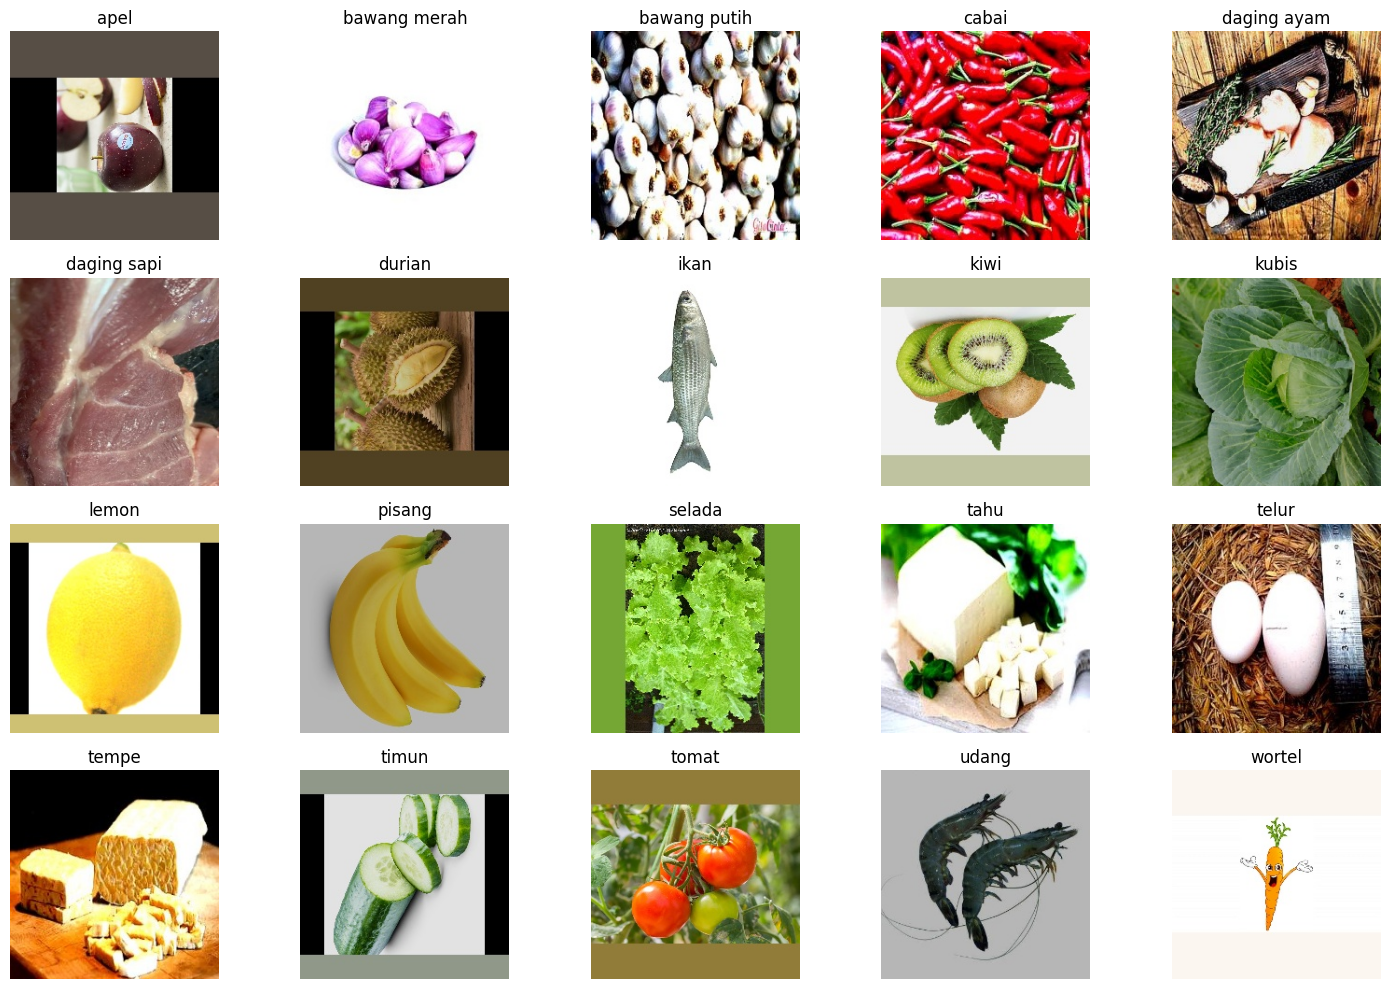

In [ ]:
classes = os.listdir(train_dir)

plt.figure(figsize=(15,10))
for i, class_name in enumerate(classes[:20]):
    class_path = os.path.join(train_dir, class_name)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)
    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# CNN  Architecture  Model 1

CONFIG

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 16
NUM_CLASSES = 20
EPOCHS = 15

Data Loading

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 8200 files belonging to 20 classes.
Found 2340 files belonging to 20 classes.
Found 1200 files belonging to 20 classes.


In [ ]:
class_names = train_dataset.class_names

print("Class Names :")
print(class_names)

print("\nJumlah Kelas :", len(class_names))

Class Names :
['apel', 'bawang merah', 'bawang putih', 'cabai', 'daging ayam', 'daging sapi', 'durian', 'ikan', 'kiwi', 'kubis', 'lemon', 'pisang', 'selada', 'tahu', 'telur', 'tempe', 'timun', 'tomat', 'udang', 'wortel']

Jumlah Kelas : 20


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)

])

In [ ]:
class StopAtAccuracy(Callback):
    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        if val_acc >= 0.90:
            print("\nValidation Accuracy mencapai 90%")
            self.model.stop_training = True

Custom Callback

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/CAPSTONE_AI_Engginer_ISMA/model_1_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

custom_stop = StopAtAccuracy()

Arcithecture Model 2 CNN IMPROVE

In [ ]:
model = Sequential([
    # AUGMENTATION
    data_augmentation,

    # NORMALIZATION
    tf.keras.layers.Rescaling(1./255),

    # BLOCK 1
    Conv2D(
        32,
        (3,3),
        padding='same',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    # BLOCK 2
    Conv2D(
        64,
        (3,3),
        padding='same'
    ),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    # BLOCK 3
    Conv2D(
        128,
        (3,3),
        padding='same'
    ),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    # GLOBAL AVERAGE POOLING
    GlobalAveragePooling2D(),

    # DENSE LAYER
    Dense(256),
    Activation('relu'),
    Dropout(0.5),

    # OUTPUT
    Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint,
        custom_stop
    ]
)

Epoch 1/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2535 - loss: 2.3515
Epoch 1: val_accuracy improved from None to 0.38077, saving model to /content/drive/MyDrive/CAPSTONE_AI_Engginer_ISMA/model_1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CAPSTONE_AI_Engginer_ISMA/model_1_best.keras
513/513 ━━━━━━━━━━━━━━━━━━━━ 3942s 8s/step - accuracy: 0.3174 - loss: 2.0940 - val_accuracy: 0.3808 - val_loss: 1.8302 - learning_rate: 0.0010
Epoch 2/15
512/513 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4114 - loss: 1.7605
Epoch 2: val_accuracy improved from 0.38077 to 0.47735, saving model to /content/drive/MyDrive/CAPSTONE_AI_Engginer_ISMA/model_1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/CAPSTONE_AI_Engginer_ISMA/model_1_best.keras
513/513 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.4277 - loss: 1.7151 - val_accuracy: 0.4774 - val_loss: 1.6401 - learning_rate: 0.0010
Epoch 3/15
512/513 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accu

Save last model 1

In [ ]:
model.save(
    "/content/drive/MyDrive/CAPSTONE_AI_Engginer_ISMA/model_1_last.keras"
)

Plot model Accuracy and Loss

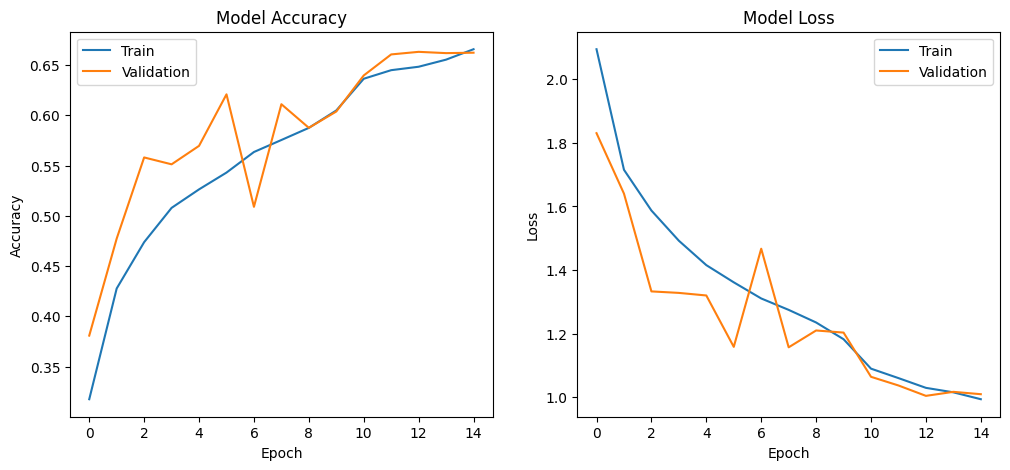

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_dataset)

print("Test Accuracy :", test_acc)
print("Test Loss :", test_loss)

75/75 ━━━━━━━━━━━━━━━━━━━━ 454s 6s/step - accuracy: 0.6750 - loss: 0.9765
Test Accuracy : 0.675000011920929
Test Loss : 0.9764624238014221


In [ ]:
y_true = np.concatenate([
    y for x, y in test_dataset
])

y_pred_probs = model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)

75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

        apel       0.76      0.87      0.81        60
bawang merah       0.87      0.87      0.87        60
bawang putih       0.55      0.27      0.36        60
       cabai       0.49      0.72      0.59        60
 daging ayam       0.62      0.72      0.67        60
 daging sapi       0.86      1.00      0.92        60
      durian       0.47      0.83      0.60        60
        ikan       0.62      0.75      0.68        60
        kiwi       0.94      0.52      0.67        60
       kubis       0.64      0.73      0.68        60
       lemon       0.53      0.55      0.54        60
      pisang       0.73      0.45      0.56        60
      selada       0.63      0.83      0.72        60
        tahu       0.89      0.52      0.65        60
       telur       0.69      0.68      0.69        60
       tempe       0.56      0.67      0.61        60
       timun       0.78      0.23      0.36        60
       tomat       0.64    

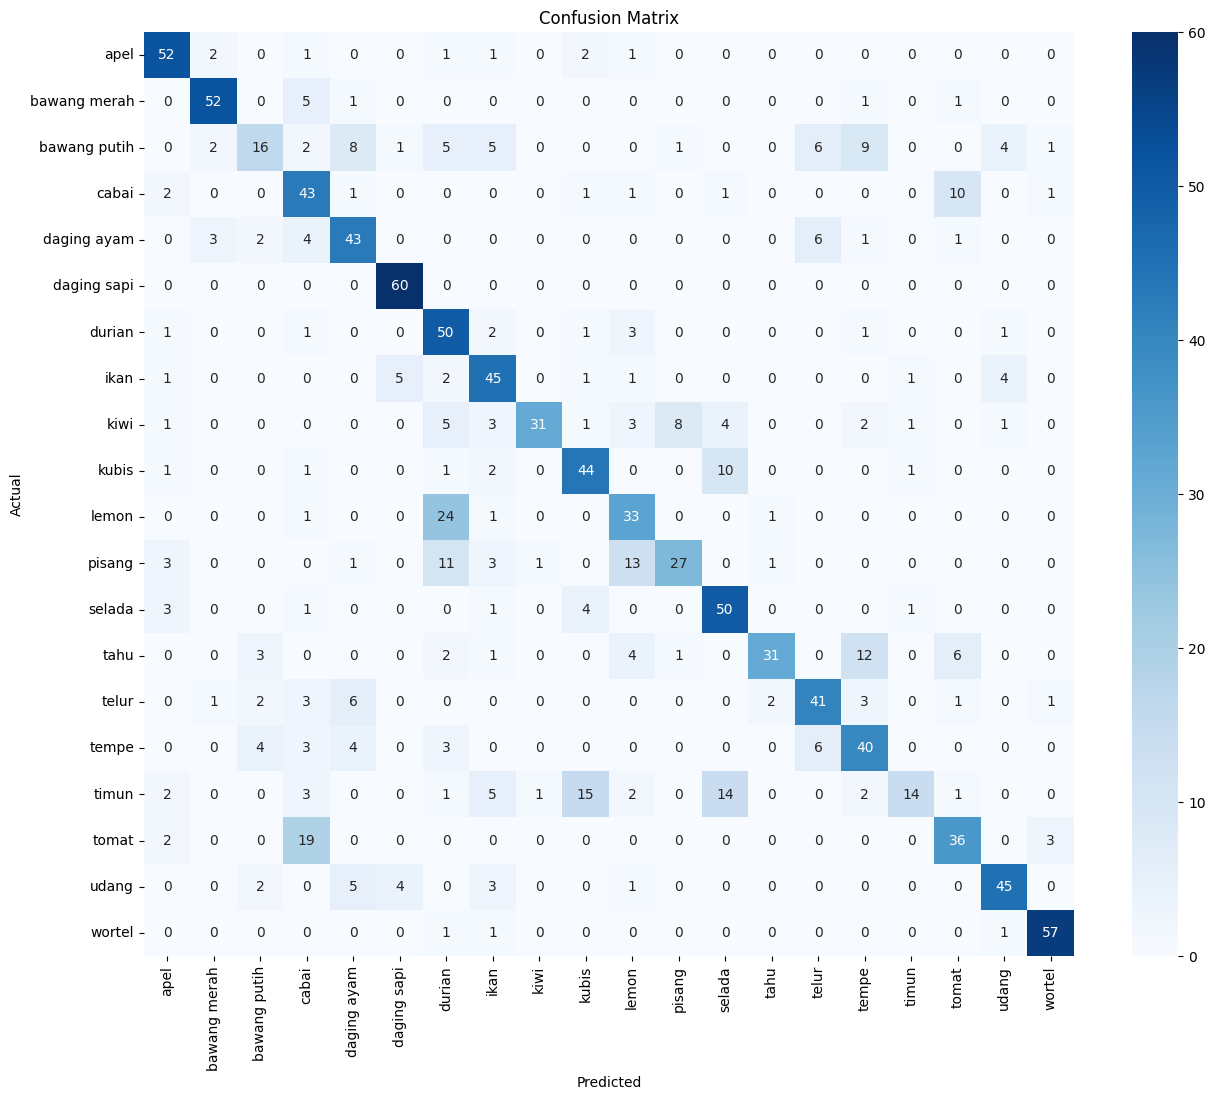

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15,12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
best_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/CAPSTONE_AI_Engginer_ISMA/model_1_best.keras"
)

# **MODEL 3 DEEP CNN**

Model 3 merupakan pengembangan dari baseline CNN sebelumnya dengan fokus utama meningkatkan kemampuan ekstraksi fitur visual. Pada model ini dilakukan beberapa penyesuaian arsitektur, yaitu:


*   menambahkan convolution block ke-4,
*   menggunakan double convolution pada setiap block
*  menurunkan dropout dari 0.5 menjadi 0.3,
*  menambahkan augmentasi
*  meningkatkan epoch training




Tujuan utama Model 2 adalah meningkatkan kemampuan model dalam membedakan kelas-kelas yang sebelumnya masih sering tertukar, seperti:

* bawang putih,
* timun,
* kiwi,
* pisang,
* kubis vs selada.

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 16
NUM_CLASSES = 20
EPOCHS = 30

In [ ]:
train_counts = count_images(train_dir)
val_counts = count_images(val_dir)
test_counts = count_images(test_dir)


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 8200 files belonging to 20 classes.
Found 2340 files belonging to 20 classes.
Found 1200 files belonging to 20 classes.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomTranslation(
        0.1,
        0.1
    )
])

CUSTOM CALLBACK : STOP AT ACCURACY

In [ ]:
class StopAtAccuracy(Callback):

    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):
        val_acc = logs.get('val_accuracy')
        if val_acc >= 0.92:
            print("\nValidation Accuracy mencapai 92%" )

            self.model.stop_training = True

CUSTOM CALLBACK : TRAINING MONITOR

In [ ]:
class TrainingMonitorCallback(Callback):

    def on_train_begin(self, logs=None):
        self.total_training_start = time.time()
        print("\n" + "="*60)
        print("TRAINING STARTED")
        print("="*60)

    # EPOCH BEGIN
    def on_epoch_begin( self, epoch, logs=None):
        self.epoch_start_time = time.time()

        print("\n" + "-"*60)
        print(f"Epoch {epoch+1} Started")
        print("-"*60)


EPOCH END

In [ ]:
    def on_epoch_end( self, epoch,logs=None):
        epoch_time = (time.time() - self.epoch_start_time)

        train_acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')

        train_loss = logs.get('loss')
        val_loss = logs.get('val_loss')

        lr = self.model.optimizer.learning_rate.numpy()

        gap = abs(train_acc - val_acc )

        print(f"\nEpoch {epoch+1} Finished")
        print(f"Time Per Epoch : {epoch_time:.2f} seconds")
        print(f"Learning Rate  : {lr:.8f}")
        print(f"Train Accuracy : {train_acc:.4f}")
        print(f"Val Accuracy   : {val_acc:.4f}")
        print(f"Train Loss     : {train_loss:.4f}")
        print(f"Val Loss       : {val_loss:.4f}")
        print(f"Train-Val Gap  : {gap:.4f}")

        # OVERFITTING WARNING
        if gap > 0.15:

            print("\nWARNING : POSSIBLE OVERFITTING DETECTED")


TRAIN END

In [ ]:
def on_train_end(self,logs=None):
        total_time = (time.time() - self.total_training_start)
        total_minutes = total_time / 60

        print("\n" + "="*60)
        print("TRAINING FINISHED")
        print("="*60)

        print(f"Total Training Time : {total_minutes:.2f} minutes")

        print("="*60)

CALLBACKS

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)
checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/capstone/model_2_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1

)

custom_stop = StopAtAccuracy()
training_monitor = TrainingMonitorCallback()

# MODEL 3 ARCHITECTURE

In [ ]:
model_2 = Sequential([
    # AUGMENTATION
    data_augmentation,

    # NORMALIZATION
    tf.keras.layers.Rescaling(1./255),

    # BLOCK 1
    Conv2D(
        32,
        (3,3),
        padding='same',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    BatchNormalization(),
    Activation('relu'),
    Conv2D(
        32,
        (3,3),
        padding='same'
    ),

    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    # BLOCK 2
    Conv2D(
        64,
        (3,3),
        padding='same'
    ),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(
        64,
        (3,3),
        padding='same'
    ),

    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    # BLOCK 3
    Conv2D(
        128,
        (3,3),
        padding='same'
    ),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(
        128,
        (3,3),
        padding='same'
    ),

    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    # BLOCK 4
    Conv2D(
        256,
        (3,3),
        padding='same'
    ),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(
        256,
        (3,3),
        padding='same'
    ),

    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    # GLOBAL AVERAGE POOLING
    GlobalAveragePooling2D(),

    # DENSE LAYER
    Dense(256),
    Activation('relu'),
    Dropout(0.3),

    # OUTPUT
    Dense(NUM_CLASSES,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


COMPILE MODEL

In [ ]:
model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

MODEL SUMMARY

In [ ]:
print("="*60)
print("MODEL 2 SUMMARY")
print("="*60)

model_2.summary()

MODEL 2 SUMMARY


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ ?                      │             

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

TRAINING

In [ ]:
history_2 = model_2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint,
        custom_stop,
        training_monitor
    ]
)

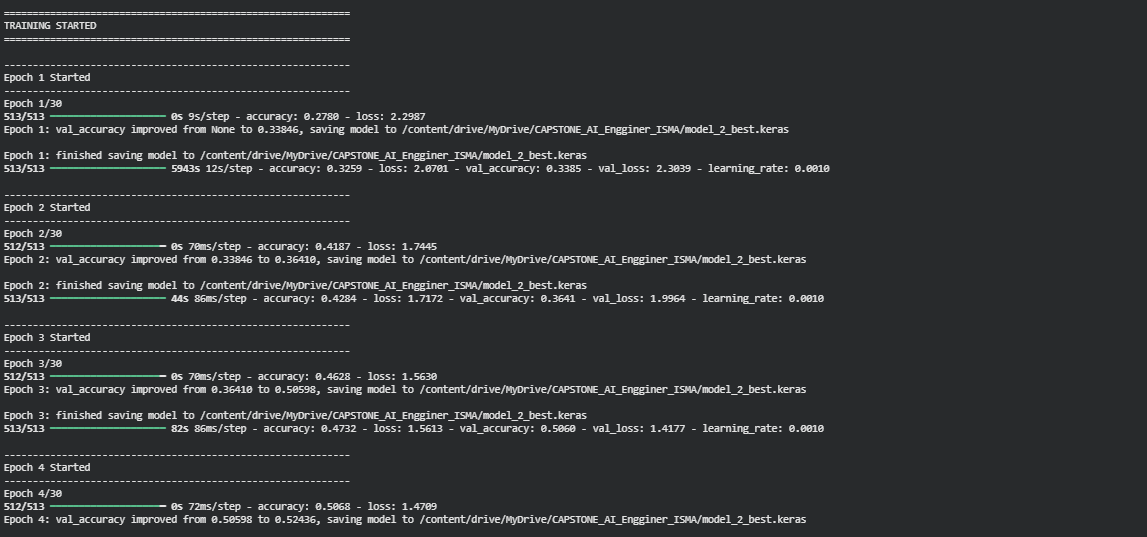

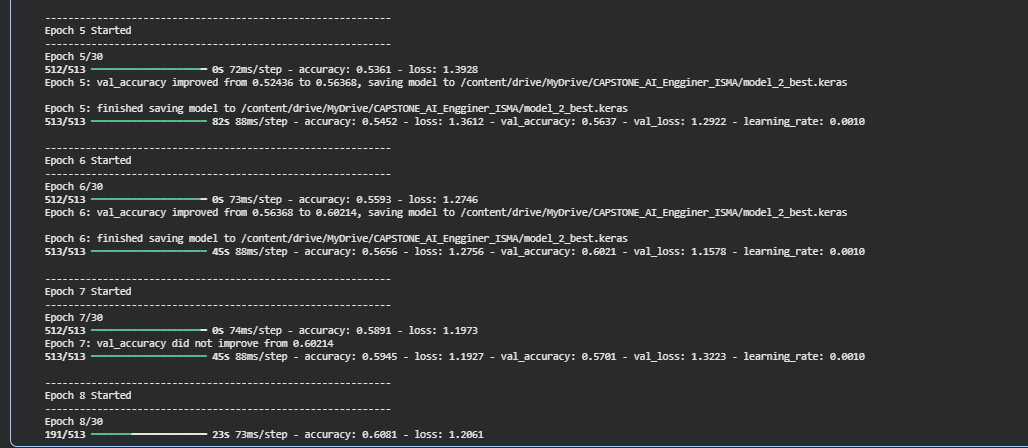

SAVE LAST MODEL

In [ ]:
model_2.save("/content/model_2_best.keras")

LOAD MODEL 3 Epoch ke 7 dan Traning Lagi

In [ ]:
model_2 = load_model("/content/model_2_best.keras")

Traning Continue Model 2

In [ ]:
history_continue = model_2.fit(
    train_dataset,
    validation_data=val_dataset,
    initial_epoch=6,
    epochs=30,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint,
        custom_stop,
        training_monitor
    ]

)


TRAINING STARTED

------------------------------------------------------------
Epoch 7 Started
------------------------------------------------------------
Epoch 7/30
513/513 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2711 - loss: 2.2964
Epoch 7: val_accuracy improved from None to 0.41282, saving model to /content/drive/MyDrive/capstone/model_2_best.keras

Epoch 7: finished saving model to /content/drive/MyDrive/capstone/model_2_best.keras
513/513 ━━━━━━━━━━━━━━━━━━━━ 3968s 8s/step - accuracy: 0.3200 - loss: 2.0712 - val_accuracy: 0.4128 - val_loss: 1.8027 - learning_rate: 0.0010

------------------------------------------------------------
Epoch 8 Started
------------------------------------------------------------
Epoch 8/30
512/513 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4044 - loss: 1.7646
Epoch 8: val_accuracy did not improve from 0.41282
513/513 ━━━━━━━━━━━━━━━━━━━━ 42s 82ms/step - accuracy: 0.4183 - loss: 1.7165 - val_accuracy: 0.3803 - val_loss: 2.0321 - learning_ra

In [ ]:
test_loss, test_acc = model_2.evaluate(test_dataset)

print("="*50)
print("TEST EVALUATION")
print("="*50)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")


75/75 ━━━━━━━━━━━━━━━━━━━━ 464s 6s/step - accuracy: 0.8358 - loss: 0.5271
TEST EVALUATION
Test Accuracy : 0.8358
Test Loss     : 0.5271


PREDICTION

In [ ]:
y_true = []
y_pred = []

class_names = test_dataset.class_names
for images, labels in test_dataset:
    predictions = model_2.predict(images, verbose=0)
    pred_labels = np.argmax(predictions, axis=1)
    y_pred.extend(pred_labels)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)


CLASSIFICATION REPORT

In [ ]:
print("\n")
print("="*50)
print("CLASSIFICATION REPORT")
print("="*50)

print(classification_report( y_true,y_pred,target_names=class_names))



CLASSIFICATION REPORT
              precision    recall  f1-score   support

        apel       0.93      0.93      0.93        60
bawang merah       0.91      0.85      0.88        60
bawang putih       0.86      0.60      0.71        60
       cabai       0.68      0.87      0.76        60
 daging ayam       0.83      0.63      0.72        60
 daging sapi       1.00      0.98      0.99        60
      durian       0.81      0.90      0.85        60
        ikan       0.68      0.93      0.79        60
        kiwi       0.95      0.88      0.91        60
       kubis       0.79      0.83      0.81        60
       lemon       0.86      0.85      0.86        60
      pisang       0.89      0.82      0.85        60
      selada       0.89      0.82      0.85        60
        tahu       0.78      0.83      0.81        60
       telur       0.82      0.88      0.85        60
       tempe       0.64      0.95      0.77        60
       timun       0.97      0.58      0.73        60
   

CONFUSION MATRIX

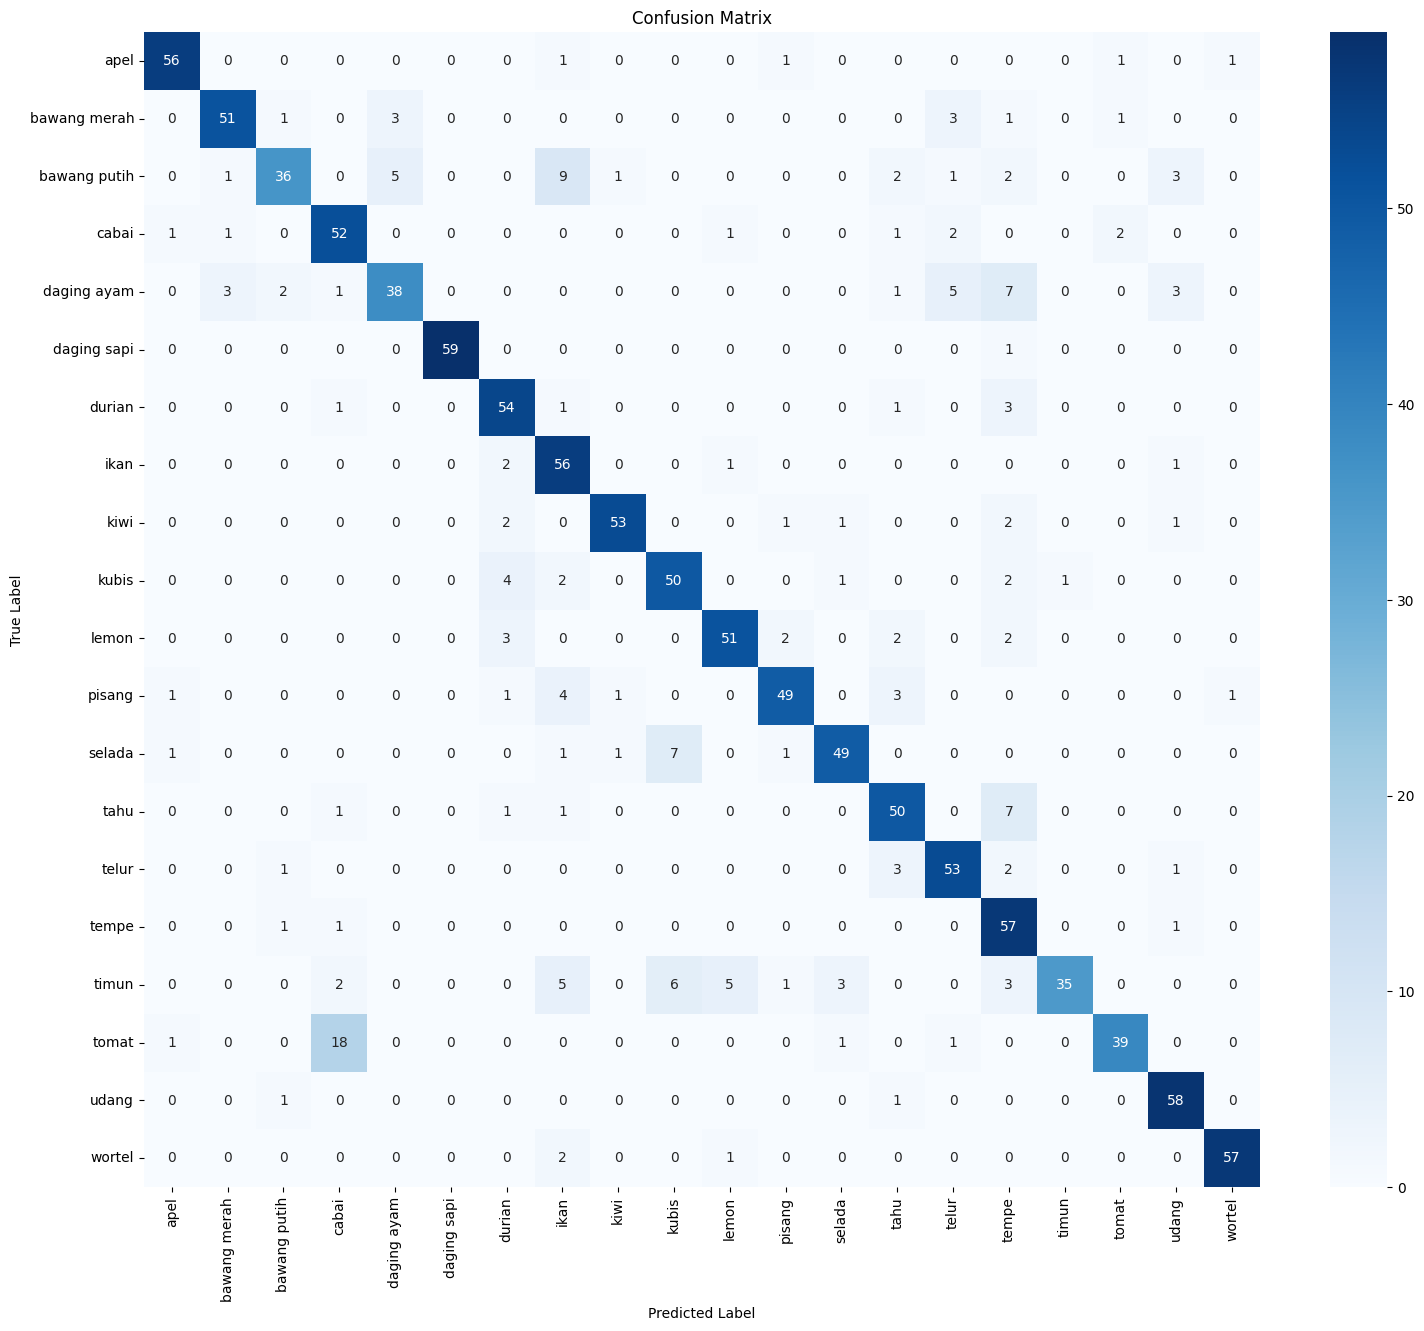

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18,15))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

MISCLASSIFICATION ANALYSIS

In [ ]:
wrong_idx = np.where(y_true != y_pred)[0]

print("\n")
print("="*50)
print("MISCLASSIFIED SAMPLES")
print("="*50)

print(f"Total Misclassified : {len(wrong_idx)}")



MISCLASSIFIED SAMPLES
Total Misclassified : 197


SHOW SOME WRONG PREDICTIONS

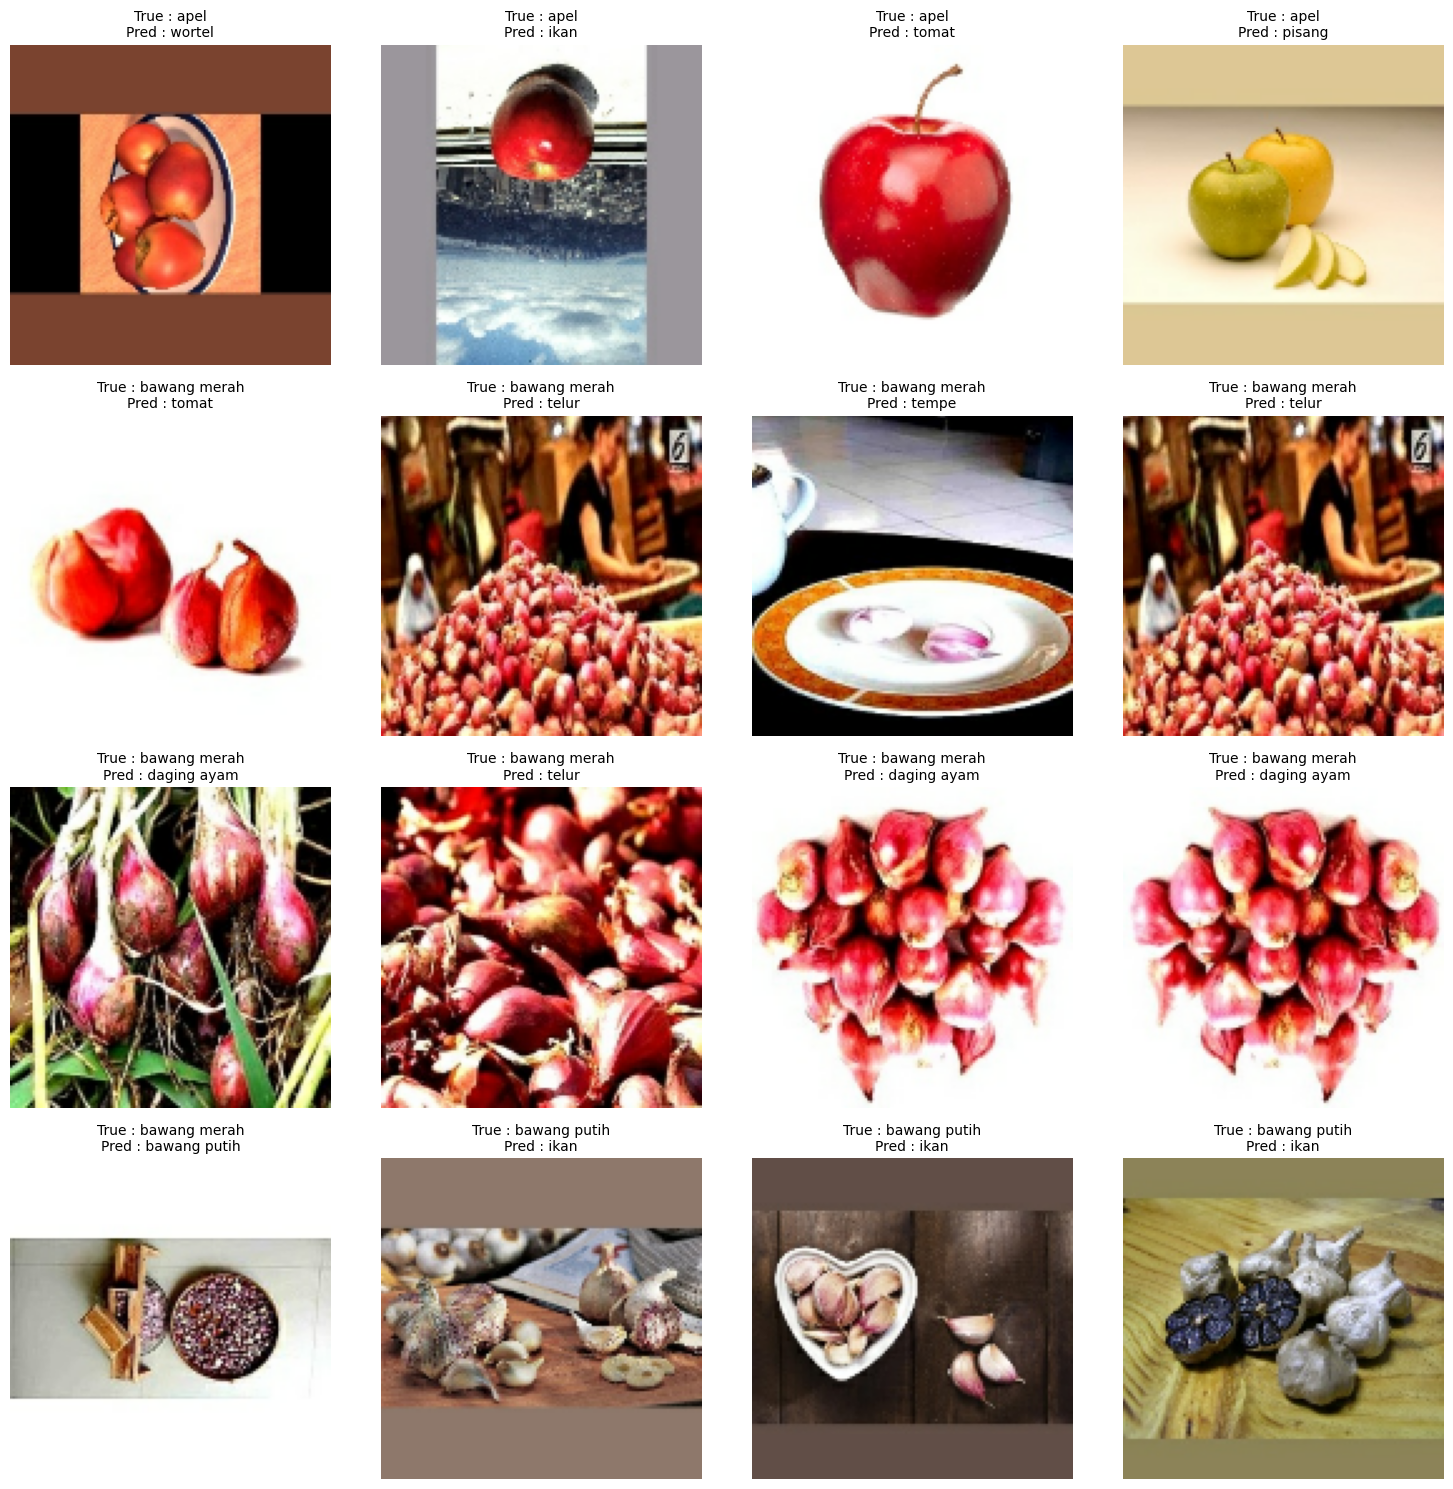

In [ ]:
# =====================================================
# COLLECT ALL TEST IMAGES
# =====================================================

all_images = []
all_labels = []

for images, labels in test_dataset:
    all_images.extend(images.numpy())
    all_labels.extend(labels.numpy())

all_images = np.array(all_images)
all_labels = np.array(all_labels)

# =====================================================
# SHOW MISCLASSIFIED IMAGES
# =====================================================

plt.figure(figsize=(15,15))
for i, idx in enumerate(wrong_idx[:16]):
    image = all_images[idx]
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]

    plt.subplot(4,4,i+1)
    plt.imshow(image.astype("uint8"))
    plt.title(
        f"True : {true_label}\nPred : {pred_label}",
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Model 4 EfficientnetB0

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 20
EPOCHS = 15

In [ ]:
train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

val_dataset = val_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (preprocess_input(x), y)
)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)

val_dataset = val_dataset.prefetch(AUTOTUNE)

test_dataset = test_dataset.prefetch(AUTOTUNE)

In [ ]:
checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/capstone/model_2_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1

)

In [ ]:
# INPUT
inputs = Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

# AUGMENTATION
x = data_augmentation(inputs)

# EFFICIENTNET
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_tensor=x
)

# FREEZE BACKBONE
base_model.trainable = False

# CLASSIFICATION HEAD
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.3)(x)
outputs = Dense(
    NUM_CLASSES,
    activation='softmax'
)(x)

# FINAL MODEL
model_3 = Model(inputs, outputs)

model_3.summary()

Model: "functional_43"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ sequential_2[2][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_5[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_6[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,382,647 (16.72 MB)

 Trainable params: 333,076 (1.27 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model_3.compile(

    optimizer=Adam(
        learning_rate=1e-4
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
history = model_3.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint,
        custom_stop,
        training_monitor
    ]
)


TRAINING STARTED

------------------------------------------------------------
Epoch 1 Started
------------------------------------------------------------
Epoch 1/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4909 - loss: 1.9798
Epoch 1: val_accuracy improved from None to 0.91538, saving model to /content/drive/MyDrive/capstone/model_2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/capstone/model_2_best.keras
513/513 ━━━━━━━━━━━━━━━━━━━━ 3868s 8s/step - accuracy: 0.7030 - loss: 1.2823 - val_accuracy: 0.9154 - val_loss: 0.4093 - learning_rate: 1.0000e-04

------------------------------------------------------------
Epoch 2 Started
------------------------------------------------------------
Epoch 2/15
512/513 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8959 - loss: 0.4364
Epoch 2: val_accuracy improved from 0.91538 to 0.94188, saving model to /content/drive/MyDrive/capstone/model_2_best.keras

Epoch 2: finished saving model to /content/drive/MyDriv

PREDICTION Model 3

In [ ]:
print("\n" + "="*60)
print("PREDICTING TEST DATA")
print("="*60)

y_true = np.concatenate([
    y for x, y in test_dataset
])

y_pred_probs = model_3.predict(test_dataset)
y_pred = np.argmax(
    y_pred_probs,
    axis=1
)


PREDICTING TEST DATA
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step


ACCURACY

In [ ]:
test_accuracy = accuracy_score(
    y_true,
    y_pred
)

print("\n" + "="*60)
print("TEST ACCURACY")
print("="*60)

print(f"Accuracy : {test_accuracy:.4f}")


TEST ACCURACY
Accuracy : 0.9433


 PRECISION RECALL F1

In [ ]:
precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("\n" + "="*60)
print("OVERALL METRICS")
print("="*60)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")



OVERALL METRICS
Precision : 0.9457
Recall    : 0.9433
F1 Score  : 0.9431


CLASSIFICATION REPORT

In [ ]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        apel       0.93      0.90      0.92        60
bawang merah       0.93      0.95      0.94        60
bawang putih       0.90      0.92      0.91        60
       cabai       0.98      0.82      0.89        60
 daging ayam       0.92      0.97      0.94        60
 daging sapi       0.98      1.00      0.99        60
      durian       0.98      1.00      0.99        60
        ikan       1.00      0.98      0.99        60
        kiwi       0.95      0.92      0.93        60
       kubis       0.83      1.00      0.91        60
       lemon       0.94      0.97      0.95        60
      pisang       1.00      0.98      0.99        60
      selada       0.94      0.78      0.85        60
        tahu       0.95      0.92      0.93        60
       telur       0.98      0.95      0.97        60
       tempe       0.98      0.95      0.97        60
       timun       0.88      0.95      0.91        60
    

CONFUSION MATRIX

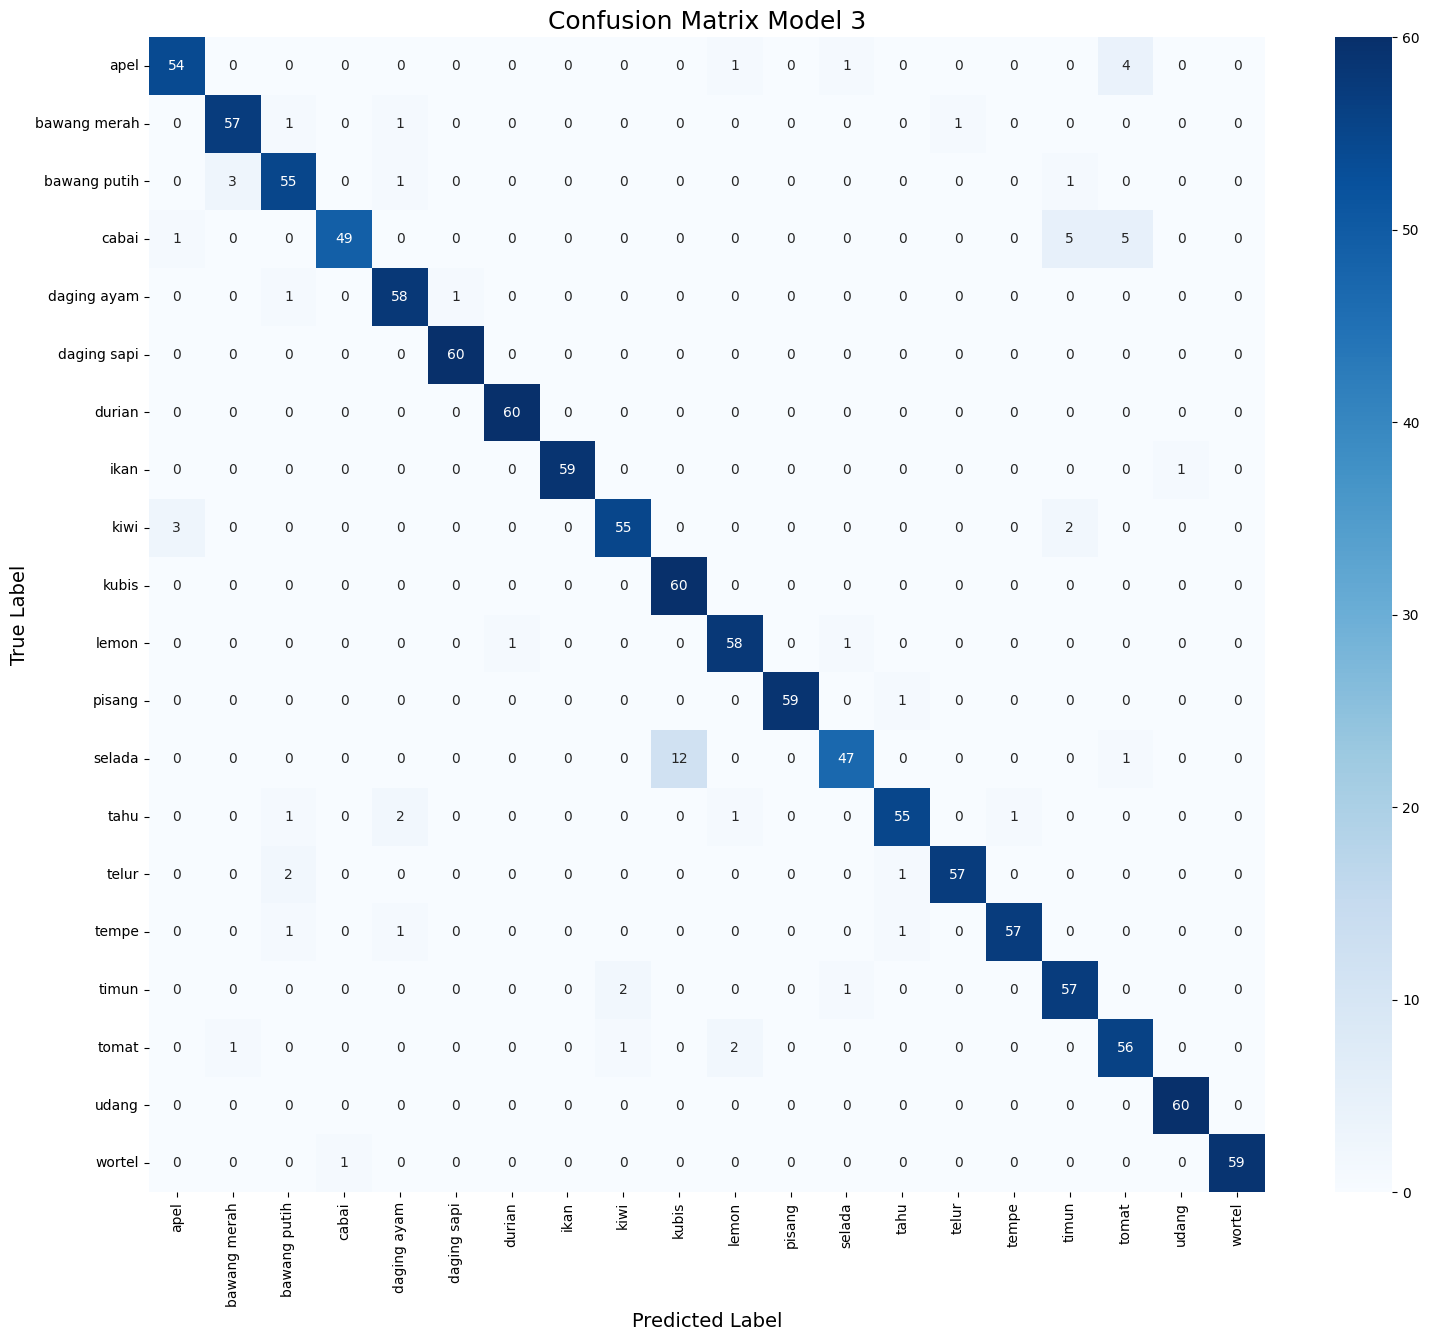

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(18,15))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix Model 3",
    fontsize=18
)

plt.xlabel(
    "Predicted Label",
    fontsize=14
)

plt.ylabel(
    "True Label",
    fontsize=14
)

plt.xticks(rotation=90)

plt.yticks(rotation=0)

plt.show()

MISCLASSIFIED SAMPLES

In [ ]:
misclassified_idx = np.where(
    y_true != y_pred
)[0]

print("\n" + "="*60)
print("MISCLASSIFIED SAMPLES")
print("="*60)

print(
    f"Total Misclassified : {len(misclassified_idx)}"
)



MISCLASSIFIED SAMPLES
Total Misclassified : 68


VISUALIZE MISCLASSIFIED

In [ ]:
plt.figure(figsize=(18,18))

for i, idx in enumerate(misclassified_idx[:25]):

    plt.subplot(5,5,i+1)

    image_batch, label_batch = next(
        iter(test_dataset.unbatch().batch(len(y_true)))
    )

    image = image_batch[idx].numpy()

    true_label = class_names[y_true[idx]]

    pred_label = class_names[y_pred[idx]]

    confidence = np.max(
        y_pred_probs[idx]
    )

    # reverse preprocessing untuk display
    image = (image - image.min()) / (
        image.max() - image.min()
    )

    plt.imshow(image)
    plt.title(
        f"True : {true_label}\nPred : {pred_label}\nConf : {confidence:.2f}",
        fontsize=9
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

Output hidden; open in https://colab.research.google.com to view.

 LOW CONFIDENCE ANALYSIS

In [ ]:
confidence_scores = np.max(
    y_pred_probs,
    axis=1
)

low_confidence_idx = np.where(
    confidence_scores < 0.60
)[0]

print("\n" + "="*60)
print("LOW CONFIDENCE ANALYSIS")
print("="*60)

print(
    f"Total Low Confidence Predictions : {len(low_confidence_idx)}"
)


LOW CONFIDENCE ANALYSIS
Total Low Confidence Predictions : 123


LAST CONV LAYER
top_conv


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1137']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


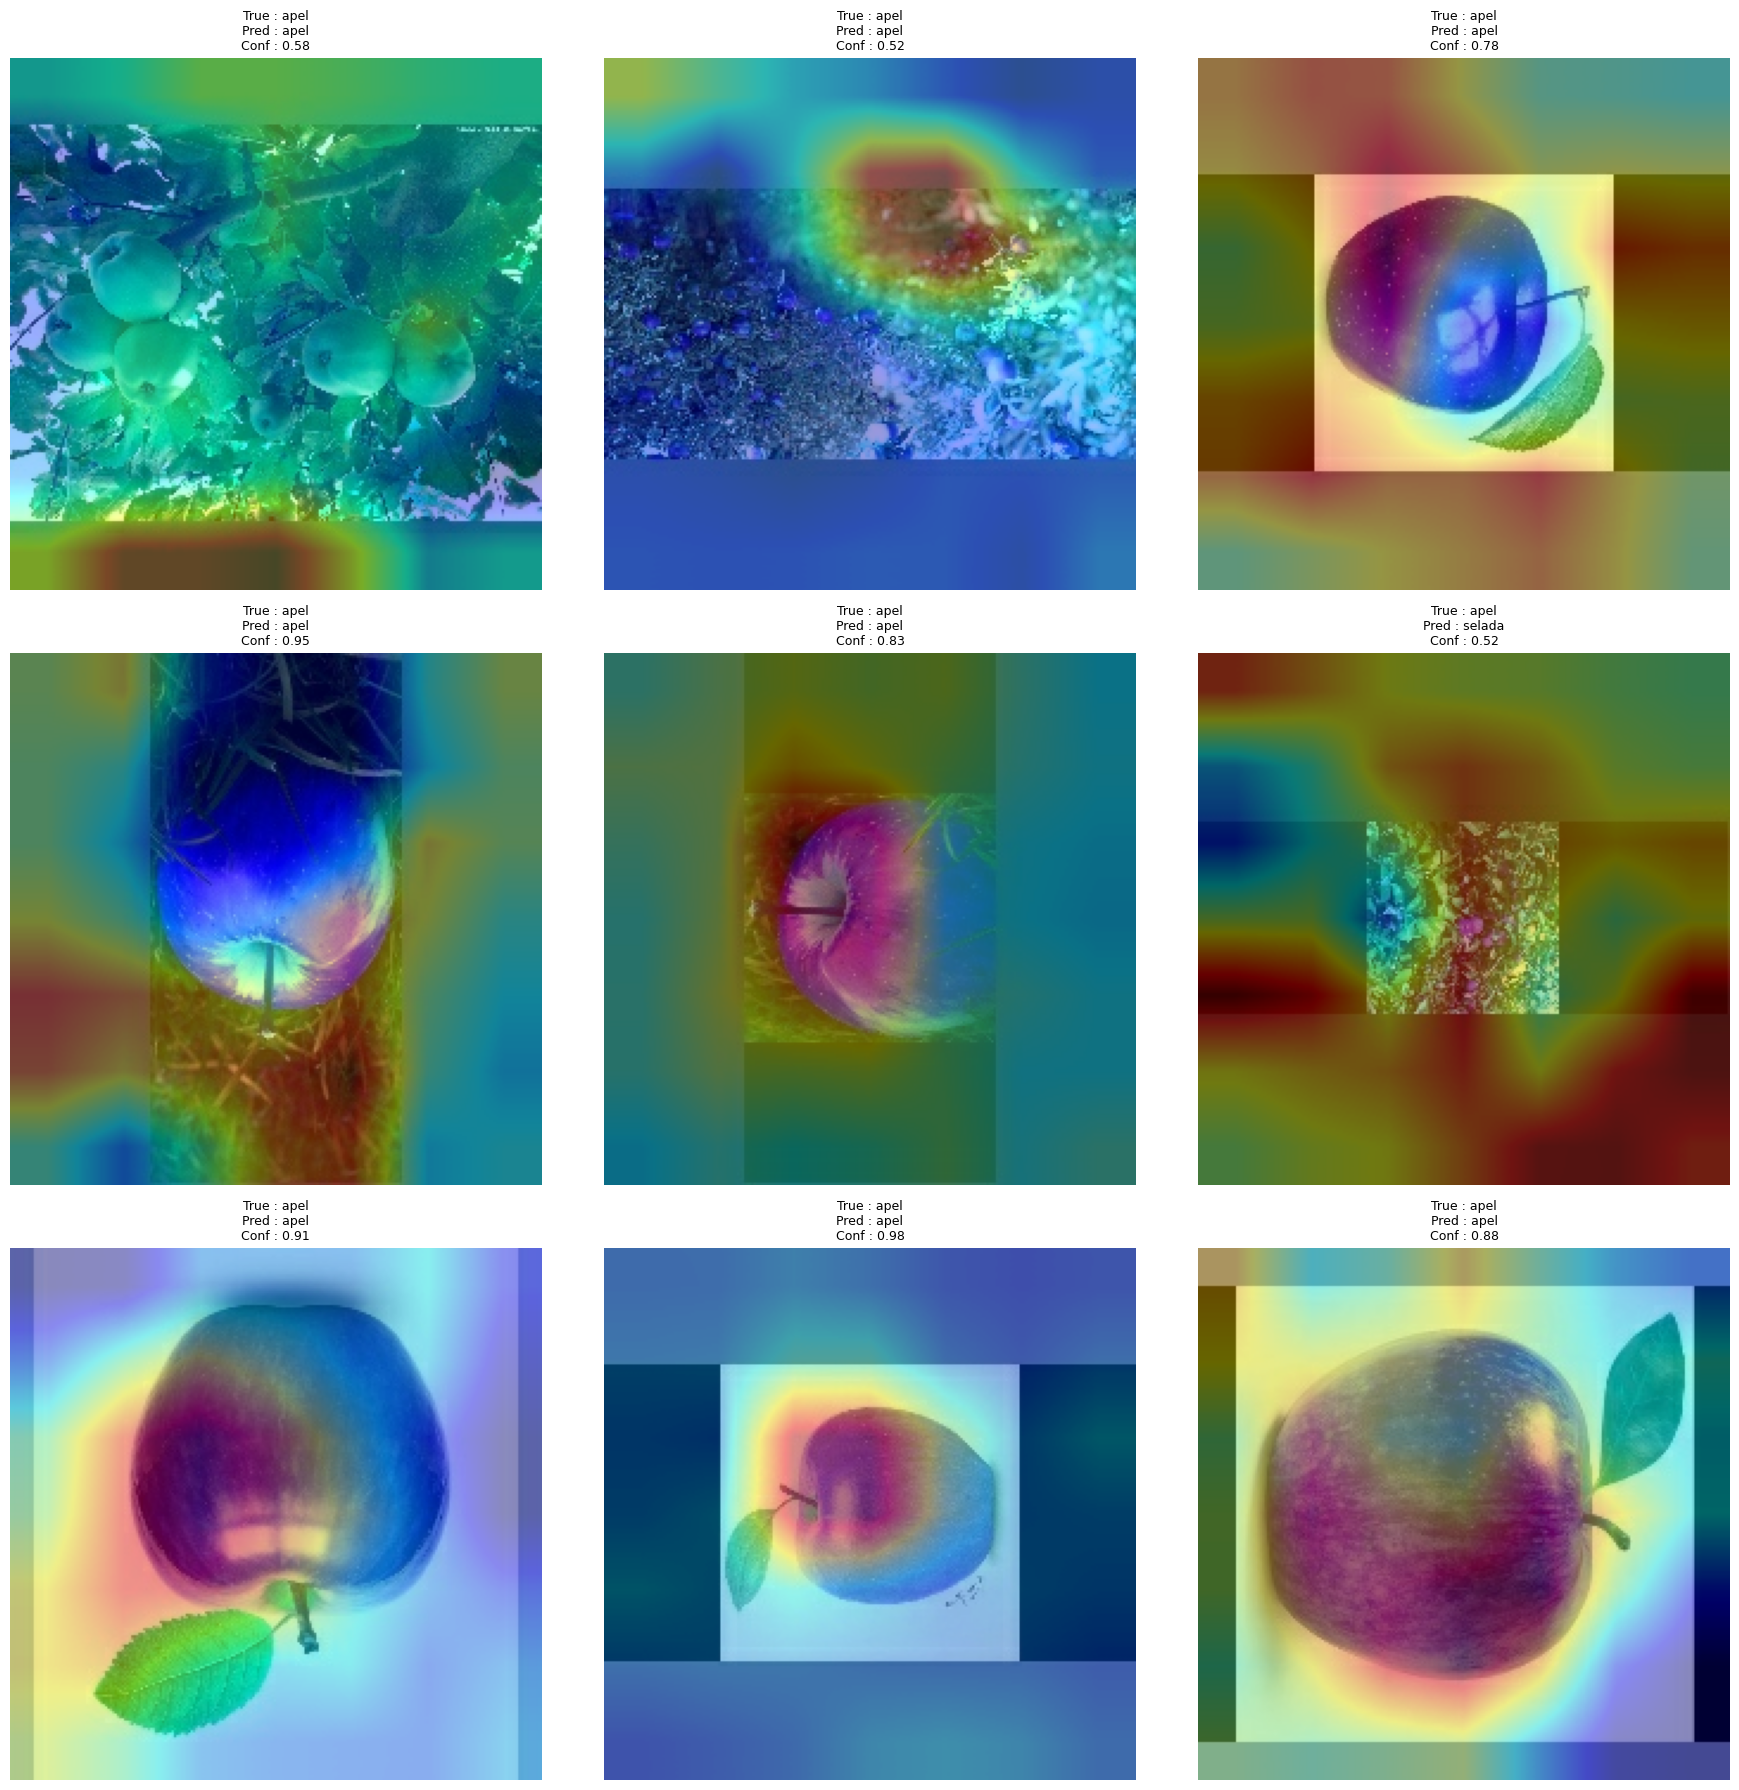

In [ ]:
# Cari layer konvolusi terakhir
last_conv_layer_name = None

for layer in reversed(model_3.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Last Conv Layer:", last_conv_layer_name)


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.math.reduce_max(heatmap)

    return heatmap.numpy()


def display_gradcam(image, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.resize(
        heatmap,
        (image.shape[1], image.shape[0])
    )

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    return cv2.addWeighted(
        image,
        1 - alpha,
        heatmap,
        alpha,
        0
    )


# Ambil satu batch dari test dataset
for image_batch, label_batch in test_dataset.take(1):
    images = image_batch.numpy()
    labels = label_batch.numpy()

class_names = test_dataset.class_names


plt.figure(figsize=(18, 18))

for i in range(9):
    img = images[i]
    img_array = np.expand_dims(img, axis=0)

    preds = model_3.predict(img_array, verbose=0)

    pred_class = np.argmax(preds[0])
    confidence = np.max(preds[0])

    heatmap = make_gradcam_heatmap(
        img_array,
        model_3,
        last_conv_layer_name
    )

    # Kembalikan ke format gambar biasa
    display_img = img.copy()
    display_img = (
        display_img - display_img.min()
    ) / (
        display_img.max() - display_img.min()
    )

    display_img = np.uint8(255 * display_img)

    gradcam_img = display_gradcam(
        display_img,
        heatmap
    )

    true_label = class_names[labels[i]]
    pred_label = class_names[pred_class]

    plt.subplot(3, 3, i + 1)
    plt.imshow(cv2.cvtColor(
        gradcam_img,
        cv2.COLOR_BGR2RGB
    ))

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {pred_label}\n"
        f"Conf: {confidence:.2f}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
!cp -r "/content/drive/MyDrive/capstone/model_3_best.keras" "/content/"

Inference

In [ ]:
# LOAD MODEL
model = tf.keras.models.load_model(
    "/content/model_3_best.keras"
)

# IMAGE PATH
image_path = "/content/dataset_food/test/timun/cucumber_16752.jpg"

# LOAD IMAGE
img = image.load_img(
    image_path,
    target_size=(224, 224)
)

# PREPROCESS
img_array = image.img_to_array(img)
img_processed = preprocess_input(img_array)
img_processed = np.expand_dims(
    img_processed,
    axis=0
)

# PREDICT
prediction = model.predict(
    img_processed,
    verbose=0
)

pred_idx = np.argmax(prediction)
confidence = np.max(prediction)
predicted_class = class_names[pred_idx]


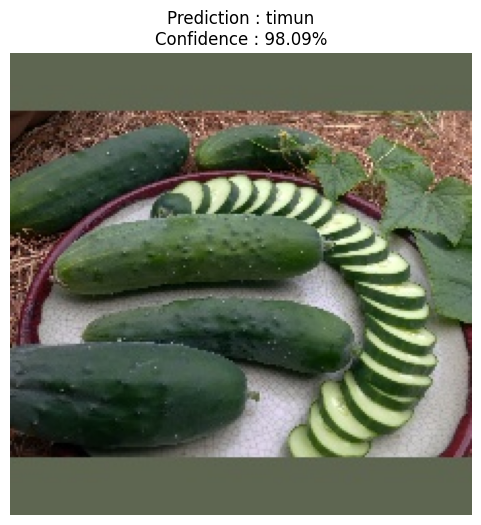

INFERENCE RESULT
Predicted Class : timun
Class Index     : 16
Confidence      : 98.09%


In [ ]:

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")

plt.title(
    f"Prediction : {predicted_class}\n"
    f"Confidence : {confidence:.2%}"
)

plt.show()

# RESULT

print("="*50)
print("INFERENCE RESULT")
print("="*50)

print(f"Predicted Class : {predicted_class}")
print(f"Class Index     : {pred_idx}")
print(f"Confidence      : {confidence:.2%}")

Menyimpan Json Dan Model

In [ ]:
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

In [ ]:
model = tf.keras.models.load_model(
    "/content/model_3_best.keras",
    compile=False
)

print("Model berhasil dimuat")

Model berhasil dimuat


In [ ]:
model = tf.keras.models.load_model(
    "/content/model_3_best.keras",
    compile=False
)

model.export(
    "/content/food_saved_model"
)

Saved artifact at '/content/food_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  133127656890512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133127656888976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133127656890704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133127656890320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133127656889552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133127615844944: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133127615845136: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133127656892048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133127656892432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133127656890896: TensorSpec(shape=(), dtype=tf.resource

In [ ]:
!zip -r food_saved_model.zip food_saved_model

  adding: food_saved_model/ (stored 0%)
  adding: food_saved_model/assets/ (stored 0%)
  adding: food_saved_model/variables/ (stored 0%)
  adding: food_saved_model/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: food_saved_model/variables/variables.index (deflated 77%)
  adding: food_saved_model/saved_model.pb (deflated 91%)
  adding: food_saved_model/fingerprint.pb (stored 0%)
